In [1]:
import os
import pandas as pd
import numpy as np
import scipy as scp
from src.wav_io import wav_metadata_reader, wav_reader
from src.spectrogram_analysis import spectrogram_resolution, spectrogram_analysis_nfft, pltSpect
from src.spl_utils import OctaveBandsCalculation, spl_calculation, pltSPL
from src.utils import calculate_cumulative_stats, representate_cumulative_stats, fs_factor

#### General parameters:

In [2]:
FontSize = 16
PSDmin,PSDmax = 30,140 # [dB re 1uPa^2/Hz]
pctls2calc = np.array([25, 50, 75, 90, 95])

NFFT = 2048
overlap_bin = 0.5
fmax_overlap = 1000 # [Hz]

#### Synthetic Data Generation:

This cell runs the script that generates an example acoustic signal.
The output WAV file is saved in the "./results" folder

In [3]:
datapath2save = r"./results"
!python -m scripts.generate_example_data --output_results {datapath2save}

INFO:__main__:...generate_example_data finalize!


#### Read/Load the signal:

In [4]:
FileName = "example_data"
WAVname = os.path.join(datapath2save,f"{FileName}.wav")
metadata_str = wav_metadata_reader(WAVname)
# print(f"Metadata read from wav file: {metadata_str}")
Nbits = metadata_str["Nbits"]
FS_uPa = metadata_str["FS_uPa"]
signal_uPa, fs, _ = wav_reader(WAVname,Nbits=Nbits,FS_uPa=FS_uPa)
signal_t = np.arange(0, len(signal_uPa) / fs, 1 / fs)
print(f"Max absolute value in signal_uPa: {np.max(np.abs(signal_uPa))}")

Max absolute value in signal_uPa: 49135293962.50446


/Users/ddietor/Documents/ddietor/LT-Acoustic-Feature-Extractor/src/wav_io.py:127: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, signal_samples = wavfile.read(str(wav_path))


#### Spectrogram resolution:

In [5]:
Tbin, Fbin, Fvalid = spectrogram_resolution(NFFT, fs, overlap=overlap_bin)
print(f"{NFFT}-NFFT and {overlap_bin*100:.0f}% overlap (fs:{int(fs/1e3)} kHz) -> Fbin:{Fbin:.1f} Hz, Tbin:{Tbin:.3f} s, Fvalid:{Fvalid:.1f} Hz")

2048-NFFT and 50% overlap (fs:192 kHz) -> Fbin:93.8 Hz, Tbin:0.005 s, Fvalid:187.5 Hz


### Section 1 - High-frequency analysis
#### 1.1 PSDdata 
##### 1.1.1 PSDdata calculation:

In [6]:
tspect,fspect,psd,spect_info = spectrogram_analysis_nfft(signal_uPa,fs,NFFT=NFFT,overlap=overlap_bin,plotter=False)
tspect = tspect + signal_t[0]
_,tbin,fbin,fvalid,_ = spect_info

Nvalid = np.where(fspect >= fvalid)[0][0]
fspect = fspect[Nvalid:]
psd = psd[Nvalid:,:]

PSD_high = np.column_stack([np.append(np.nan,fspect),np.vstack([tspect,psd])])

##### 1.1.2 PSDdata representation:

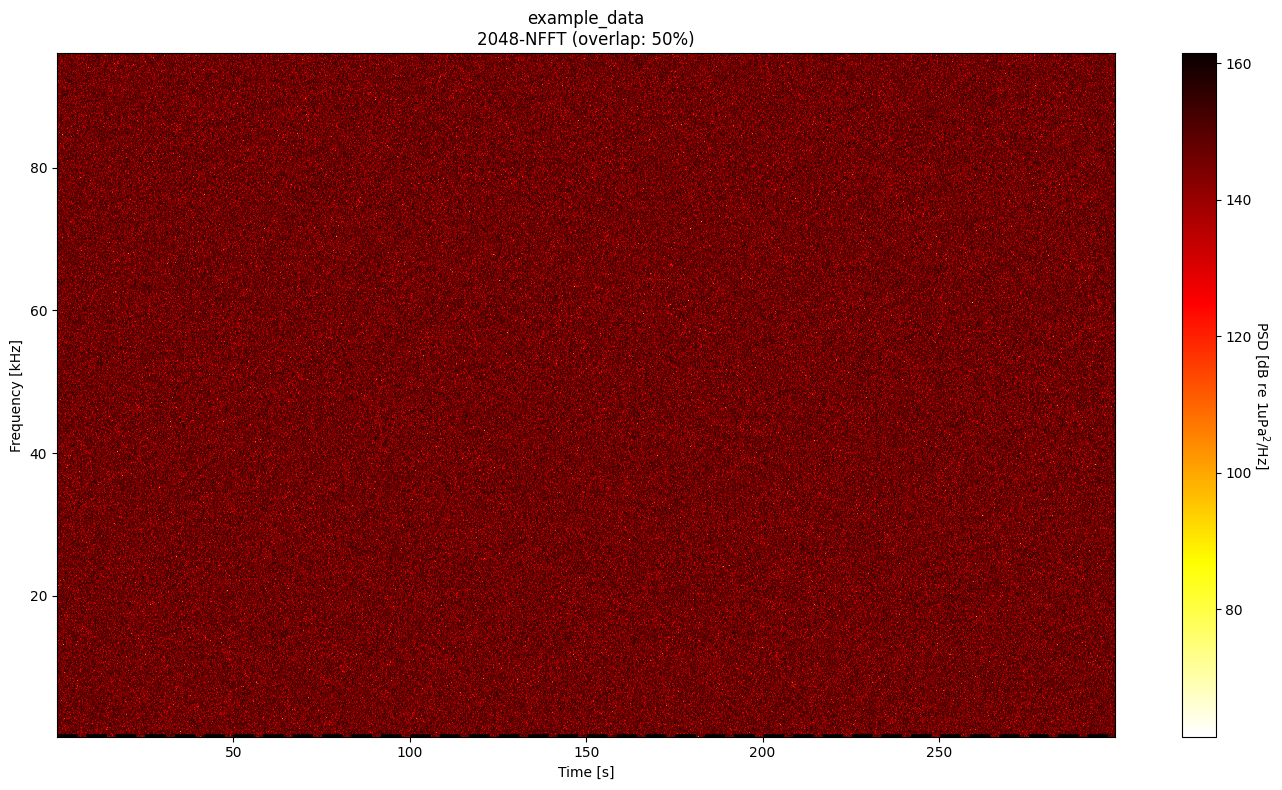

In [7]:
SpectName = FileName + '_PSDdata'
title_str = f'{FileName}\n{NFFT}-NFFT (overlap: {int(overlap_bin*100)}%)'
pltSpect(psd, tspect, fspect, spect_info, title_str=title_str, CbarLabel='PSD [dB re 1uPa$^2$/Hz]', path2save=datapath2save, filename=SpectName)
   

##### 1.1.3 PSDdata saver:

In [8]:
save_PSDdata_csv = False
if save_PSDdata_csv:
    psd2csv = np.column_stack([np.append(np.nan,fspect),np.vstack([tspect,psd])])
    csvData = pd.DataFrame(psd2csv)
    csvData.to_csv(os.path.join(datapath2save,SpectName+'.csv'),index=False,header=False,sep =';')  

#### 1.2 PSDdata_cum
##### 1.2.1 PSDdata_cum calculation:

In [9]:
psd_cum = calculate_cumulative_stats(data=psd,x=fspect,pctls=pctls2calc)
display(psd_cum)

,Freq_Hz,Mean,PCTL25,PCTL50,PCTL75,PCTL90,PCTL95
0,281.25,148.852078,143.403356,147.265213,150.252378,152.473833,153.620871
1,375.00,148.833725,143.365677,147.221046,150.280214,152.473704,153.595855
2,468.75,148.837704,143.452893,147.269835,150.266260,152.447543,153.585412
3,562.50,148.837085,143.457359,147.284717,150.237157,152.444388,153.588069
4,656.25,148.816231,143.435504,147.194980,150.213830,152.437104,153.579819
...,...,...,...,...,...,...,...
1017,95625.00,148.848291,143.421273,147.221781,150.247954,152.502111,153.654469
1018,95718.75,148.827522,143.393361,147.224330,150.247267,152.476492,153.608444
1019,95812.50,148.825086,143.407640,147.263473,150.240677,152.456755,153.586509
1020,95906.25,148.825358,143.378514,147.204075,150.217554,152.432424,153.626986


##### 1.2.2 PSDdata_cum representation:

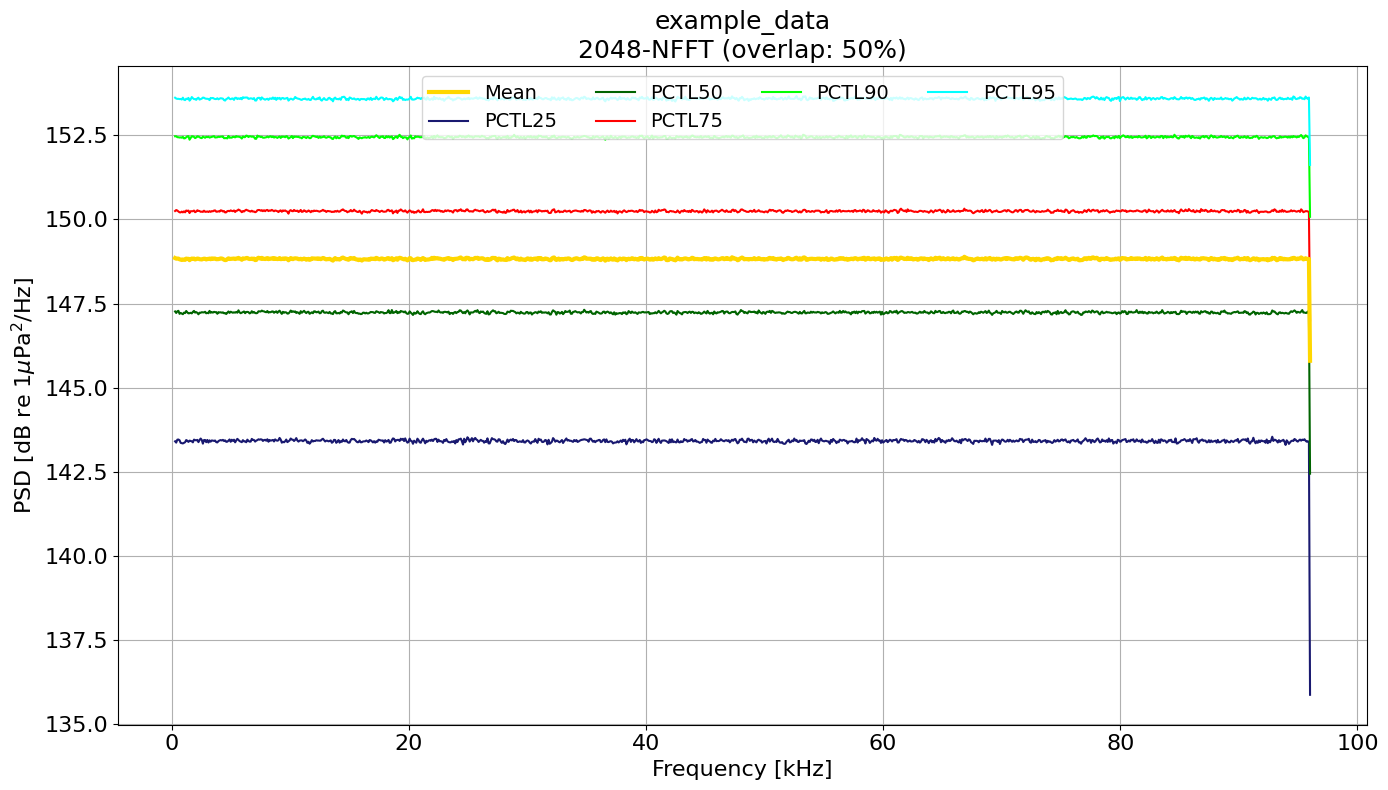

In [10]:
PSDcumName = FileName + '_PSDdata_cum'
title_str = f'{FileName}\n{NFFT}-NFFT (overlap: {int(overlap_bin*100)}%)'
representate_cumulative_stats(data_cum=psd_cum,ylabel=r"PSD [dB re 1$\mu$Pa$^2$/Hz]",xmin=None,xmax=None,FontSize=FontSize,title_str=title_str,path2save=datapath2save,filename=PSDcumName)

##### 1.2.3 PSDdata_cum saver:

In [11]:
save_PSDdataCum_csv = True
if save_PSDdataCum_csv:
    psd_cum.to_csv(os.path.join(datapath2save,PSDcumName+'.csv'),index=False,header=True,sep =';')  


#### 1.3 SPLdata 
##### 1.3.1 SPLdata calculation:

In [12]:
OctaveBands_fs = OctaveBandsCalculation(fs,octave=1/3) 
OctaveBands = OctaveBands_fs[OctaveBands_fs['fini'] >= min(fspect[fspect>=fvalid])]
OctaveBands = OctaveBands.reset_index(drop=True)
spl = spl_calculation(tspect,fspect,psd,OctaveBands)

SPL_high = np.column_stack([np.append(np.nan,OctaveBands['fc'].values),np.vstack([tspect,spl])])

##### 1.3.2 SPLdata representation:

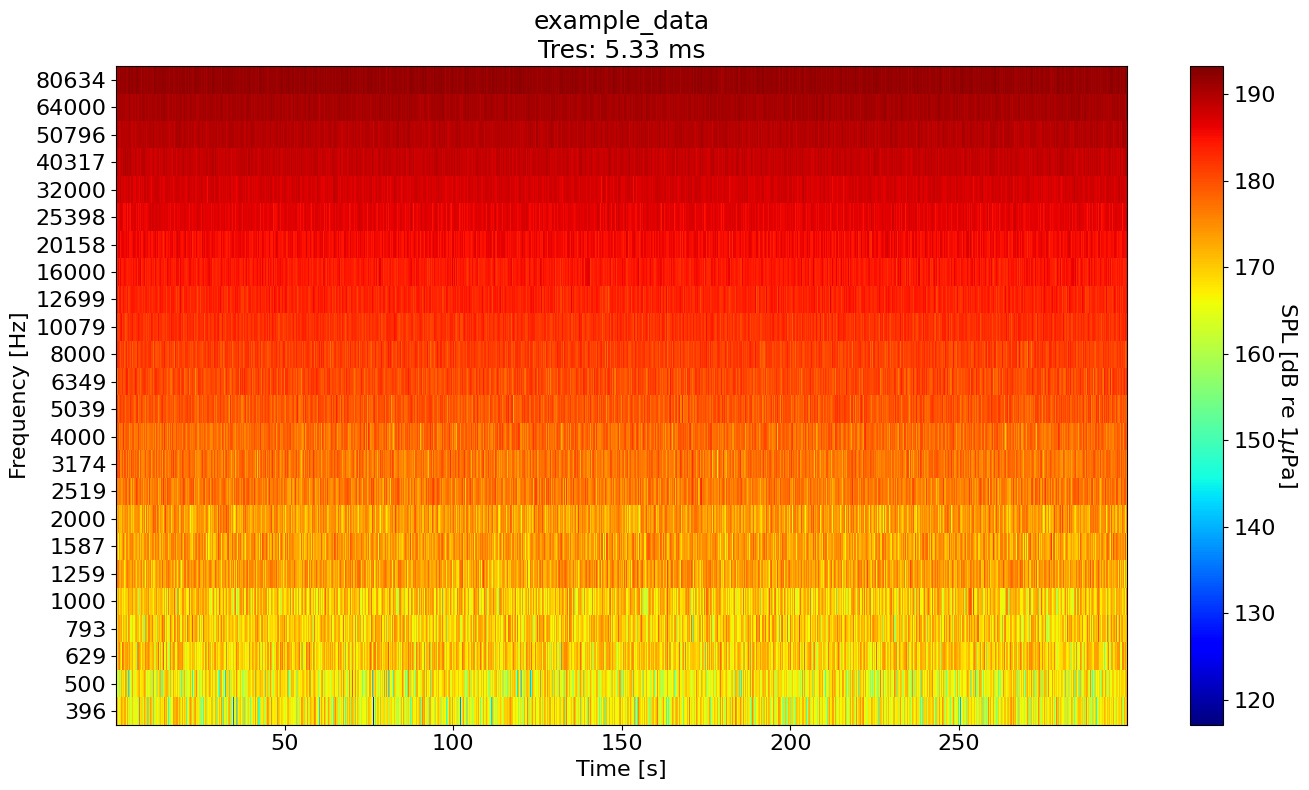

In [13]:
SplName = FileName + '_SPLdata'
pltSPL(spl, tspect, OctaveBands, FileName=FileName, FontSize=FontSize, c_map='jet', path2save=datapath2save, filename=SplName)

##### 1.3.3 SPLdata saver:

In [14]:
save_SPLdata_csv = True
if save_SPLdata_csv:
    spl2csv = np.column_stack([np.append(np.nan,OctaveBands['fc'].values),np.vstack([tspect,spl])])
    csvData = pd.DataFrame(spl2csv)
    csvData.to_csv(os.path.join(datapath2save,SplName+'.csv'),index=False,header=False,sep =';') 

#### 1.4 SPLdata_cum
##### 1.4.1 SPLdata_cum calculation:

In [16]:
spl_cum = calculate_cumulative_stats(data=spl,x=OctaveBands['fc'].values,pctls=pctls2calc)
display(spl_cum)

,Freq_Hz,Mean,PCTL25,PCTL50,PCTL75,PCTL90,PCTL95
0,396.850263,168.553438,163.085390,166.940759,169.999927,172.193417,173.315567
1,500.000000,168.557417,163.172606,166.989548,169.985972,172.167256,173.305125
2,629.960525,171.556683,167.716558,170.410330,172.819380,174.714256,175.784369
3,793.700526,171.532142,167.644768,170.372714,172.812985,174.736802,175.784179
4,1000.000000,171.537011,167.668445,170.369872,172.802390,174.737450,175.785122
5,1259.921050,174.564652,171.919006,173.899392,175.709220,177.197500,178.025871
6,1587.401052,174.559383,171.900822,173.875781,175.705548,177.226713,178.058799
7,2000.000000,174.567926,171.922407,173.922367,175.727432,177.189252,177.999154
8,2519.842100,176.995232,175.067099,176.582439,178.002366,179.200986,179.887663
9,3174.802104,177.578995,175.798139,177.225251,178.550704,179.662876,180.313134


##### 1.4.2 SPLdata_cum representation:

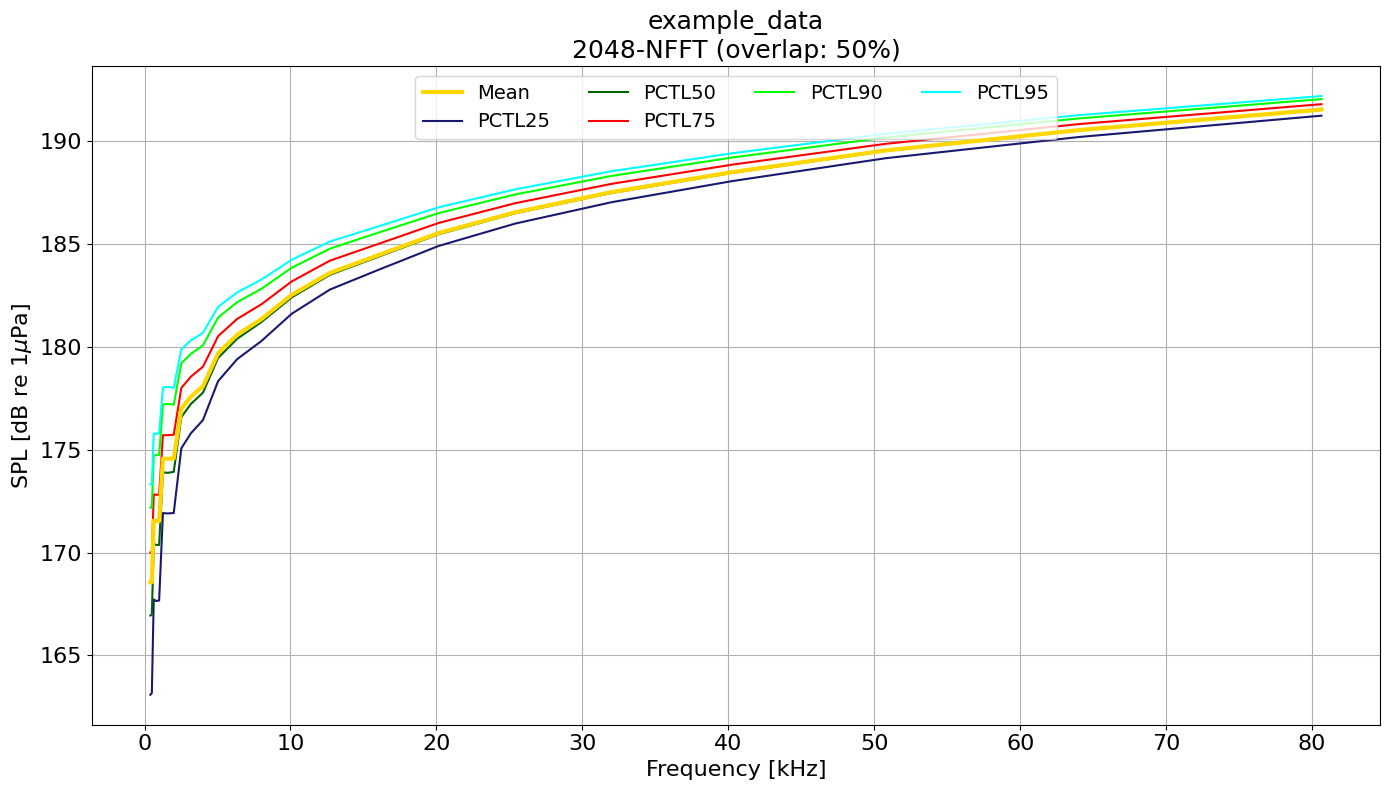

In [17]:
SPLcumName = FileName + '_SPLdata_cum'
title_str = f'{FileName}\n{NFFT}-NFFT (overlap: {int(overlap_bin*100)}%)'
representate_cumulative_stats(data_cum=spl_cum,ylabel=r"SPL [dB re 1$\mu$Pa]",xmin=None,xmax=None,FontSize=FontSize,title_str=title_str,path2save=datapath2save,filename=SPLcumName)

##### 1.4.3 SPLdata_cum saver:

In [18]:
save_SPLdataCum_csv = True
if save_SPLdataCum_csv:
    spl_cum.to_csv(os.path.join(datapath2save,SPLcumName+'.csv'),index=False,header=True,sep =';')  

### Section 2 - Low-frequency analysis
#### 2.0 Signal decimation: 

In [ ]:
factor_resamp,fs_resamp_expect = fs_factor(fs, fmax_overlap)
f_antialiasign = (fs_resamp_expect/2)*0.8 # [Hz]
signal_resamp = scp.signal.decimate(signal_uPa, factor_resamp)
fs_resamp = fs/factor_resamp

#### 2.1 PSDdata (low)
##### 2.1.1 PSDdata (low) calculation:

In [ ]:
tspect,fspect,psd,spect_info = spectrogram_analysis_nfft(signal_resamp,fs_resamp,NFFT=NFFT,overlap=overlap_bin,plotter=0)
tspect = tspect + signal_t[0]
_,tbin,fbin,fvalid,_ = spect_info

Nvalid = np.where(fspect >= fvalid)[0][0]
fspect = fspect[Nvalid:]
psd = psd[Nvalid:,:]

PSD_low = np.column_stack([np.append(np.nan,fspect),np.vstack([tspect,psd])])

##### 2.1.2 PSDdata (low) representation:

In [ ]:
SpectName = FileName + '_low_PSDdata'
title_str = f'{FileName}\n{NFFT}-NFFT (overlap: {int(overlap_bin*100)}%)'
pltSpect(psd, tspect, fspect, spect_info, title_str=title_str, CbarLabel='PSD [dB re 1uPa$^2$/Hz]', path2save=datapath2save, filename=SpectName)

##### 2.1.3 PSDdata (low) saver:

In [ ]:
save_low_PSDdata_csv = True
if save_low_PSDdata_csv:
    psd2csv = np.column_stack([np.append(np.nan,fspect),np.vstack([tspect,psd])])
    csvData = pd.DataFrame(psd2csv)
    csvData.to_csv(os.path.join(datapath2save,SpectName+'.csv'),index=False,header=False,sep =';')  

#### 2.2 PSDdata_cum (low)
##### 2.2.1 PSDdata_cum (low) calculation:

In [ ]:
psd_cum = calculate_cumulative_stats(data=psd,x=fspect,pctls=pctls2calc)
display(psd_cum)